In [323]:
#importing libraries
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd
import numpy as np
#url of particular page
def info_scrap(url):
#url="https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off"
    page = requests.get(url)
    soup = BeautifulSoup(page.text)
#offer price of the laptops
    Discount_price=[]
    for i in soup.find_all("div",class_="Nx9bqj _4b5DiR"):
        Discount_price.append(i.text)
#print(price)
#Rating of laptops
    rating=[]
    for i in soup.find_all("div",class_="XQDdHH"):
        rating.append(i.text)
    if len(rating)!=len(Discount_price):
        if len(rating)<len(Discount_price):
            for i in range(len(rating),len(Discount_price)):
                rating.append(np.nan)
        if len(rating)>len(Discount_price):
            rating=rating[:len(Discount_price)]
#print(rating)
#overall information of laptop
    info=[]
    for i in soup.find_all("li",class_="J+igdf"):
        info.append(i.text)
#extracting RAM and Storage of laptops from information
    flat_data = []
    for item in info:
        if isinstance(item, list): 
            flat_data.extend(item)
        else:
            flat_data.append(item)
    pattern = r'\b\d+\s?GB\b'
    gb_details = []
    for item in flat_data:
        matches = re.finditer(pattern, item)
        for match in matches:
            gb_details.append(match.group())
#print("Extracted GB details:", gb_details)
    RAM = []
    Storage= []
    for detail in gb_details:
        gb_value = int(detail.split()[0].replace('GB',''))
        if gb_value < 17:
            RAM.append(detail)
        else:
            Storage.append(detail)
    if len(RAM)!=len(Discount_price):
        if len(RAM)<len(Discount_price):
            for i in range(len(RAM),len(Discount_price)):
                RAM.append(np.nan)
        if len(RAM)>len(Discount_price):
            RAM=RAM[:len(Discount_price)]
    if len(Storage)!=len(Discount_price):
        if len(Storage)<len(Discount_price):
            for i in range(len(Storage),len(Discount_price)):
                Storage.append(np.nan)
        if len(Storage)>len(Discount_price):
            Storage=Storage[:len(Discount_price)]
#print("RAM:",RAM)
#print("Storage:",Storage)
#Extracting Processor from the information
    processors = []
    processor_pattern = r'(i[3579]|M1|M2|Ryzen \d)'
    for item in info:
        processor_match = re.search(processor_pattern, item, re.IGNORECASE)
        if processor_match:
            processors.append(processor_match.group())
    if len(processors)!=len(Discount_price):
        if len(processors)<len(Discount_price):
            for i in range(len(processors),len(Discount_price)):
                processors.append(np.nan)
        if len(processors)>len(Discount_price):
            processors=processors[:len(Discount_price)]
#print(processors)
#Extracting Windows of laptops from information
    windows = []
    windows_pattern = r'Windows\s+(11|12)'
    for item in info:
        windows_match = re.search(windows_pattern, item, re.IGNORECASE)
        if windows_match:
            windows.append(windows_match.group())
    if len(windows)!=len(Discount_price):
        if len(windows)<len(Discount_price):
            for i in range(len(windows),len(Discount_price)):
                windows.append(np.nan)
        if len(windows)>len(Discount_price):
            windows=windows[:len(Discount_price)]
#print(windows)
#actual price of laptops
    Actual_price=[]
    for i in soup.find_all("div",class_="yRaY8j ZYYwLA"):
        Actual_price.append(i.text)
    if len(Actual_price)!=len(Discount_price):
        if len(Actual_price)<len(Discount_price):
            for i in range(len(Actual_price),len(Discount_price)):
                Actual_price.append(np.nan)
        if len(Actual_price)>len(Discount_price):
            Actual_price=Actual_price[:len(Discount_price)]
#print(Actual_price)
#Name of the laptop
    Name=[]
    for i in soup.find_all("div",class_="KzDlHZ"):
        Name.append(i.get_text().split()[0])
    if len(Name)!=len(Discount_price):
        if len(Name)<len(Discount_price):
            for i in range(len(Name),len(Discount_price)):
                Name=Name.append(np.nan)
        if len(Name)>len(Discount_price):
            Name=Name[:len(Discount_price)]
#print(Name)
    df1=pd.DataFrame({"Brand":Name,"Actual_price":Actual_price,"Discount_price":Discount_price,"rating":rating,"RAM":RAM,"Storage":Storage,"processors":processors,"windows":windows,})
    return df1
res1=info_scrap(url="https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off")
res1

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,CHUWI,"₹34,990","₹15,990",3.7,8GB,256GB,i5,Windows 11
1,HP,"₹92,110","₹73,999",4.4,8 GB,256 GB,i5,Windows 11
2,MSI,"₹70,990","₹54,990",4.3,16 GB,512 GB,i5,Windows 11
3,SAMSUNG,"₹82,500","₹56,990",4.5,16 GB,512 GB,i3,Windows 11
4,ASUS,"₹54,990","₹35,990",4.3,16 GB,512 GB,i3,Windows 11
5,CHUWI,"₹34,990","₹17,990",4.1,8 GB,512 GB,i5,Windows 11
6,Acer,"₹92,999","₹69,990",4.3,8 GB,256 GB,i5,Windows 11
7,ASUS,"₹58,990","₹33,990",4.3,16 GB,512 GB,Ryzen 3,Windows 11
8,MSI,"₹52,990","₹41,320",4.3,16 GB,512 GB,i7,Windows 11
9,ASUS,"₹32,990","₹12,990",3.8,16 GB,512 GB,i3,Windows 11


In [324]:
res2=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page=2')
res2

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,HP,"₹64,094","₹56,990",4.3,16 GB,512 GB,Ryzen 5,Windows 11
1,ASUS,"₹54,990","₹37,990",4.3,16 GB,256GB,i3,Windows 11
2,CHUWI,"₹34,990","₹15,990",3.7,8GB,256 GB,i5,Windows 11
3,HP,"₹92,110","₹73,999",4.4,8 GB,512 GB,i5,Windows 11
4,Infinix,"₹69,990","₹49,990",4.7,16 GB,512 GB,Ryzen 3,Windows 11
5,ASUS,"₹32,990","₹13,490",3.8,16 GB,256 GB,i5,Windows 11
6,CHUWI,"₹34,990","₹17,990",4.1,4 GB,256 GB,i3,Windows 11
7,CHUWI,"₹39,990","₹18,990",3.7,8 GB,512 GB,Ryzen 7,Windows 11
8,ASUS,"₹50,990","₹31,990",4.2,8 GB,512 GB,i5,Windows 11
9,MSI,"₹76,990","₹56,990",4.4,8 GB,512 GB,i5,Windows 11


In [325]:
res3=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=3')
res3

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,HP,"₹74,048","₹59,990",4.1,16 GB,512 GB,i5,Windows 11
1,MSI,"₹80,990","₹59,990",4,16 GB,512 GB,i7,Windows 11
2,CHUWI,"₹34,990","₹15,990",3.7,8GB,256GB,i3,Windows 11
3,CHUWI,"₹34,990","₹17,990",4.1,8 GB,256 GB,Ryzen 5,Windows 11
4,SAMSUNG,"₹57,499","₹39,990",4.5,8 GB,256 GB,Ryzen 5,Windows 11
5,Lenovo,"₹37,690","₹22,990",4,8 GB,512 GB,i5,Windows 11
6,Lenovo,"₹87,990","₹62,490",4.4,8 GB,512 GB,i5,Windows 11
7,ASUS,"₹74,990","₹46,990",4.4,12 GB,512 GB,i3,Windows 11
8,CHUWI,"₹39,990","₹18,990",3.7,8 GB,512 GB,i3,Windows 11
9,CHUWI,"₹59,990","₹41,990",4.2,8 GB,256 GB,i3,Windows 11


In [326]:
res4=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=4')
res4

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,Infinix,"₹99,990","₹53,990",4.3,16 GB,512 GB,i5,Windows 11
1,Acer,"₹33,999","₹15,990",3.8,8 GB,512 GB,Ryzen 7,Windows 11
2,Acer,"₹89,999","₹71,990",4.3,16 GB,512 GB,i3,Windows 11
3,Acer,"₹35,999","₹19,990",3.9,8 GB,256GB,Ryzen 5,Windows 11
4,CHUWI,"₹34,990","₹15,990",3.7,8GB,256 GB,i5,Windows 11
5,CHUWI,"₹34,990","₹17,990",4.1,8 GB,256 GB,i3,Windows 11
6,Thomson,"₹39,990","₹24,990",3.8,8 GB,256 GB,i9,Windows 11
7,ASUS,"₹66,990","₹37,900",4.2,8 GB,512 GB,Ryzen 5,Windows 11
8,CHUWI,"₹39,990","₹18,990",3.7,8 GB,256 GB,i3,Windows 11
9,CHUWI,"₹59,990","₹41,990",4.2,8 GB,512 GB,i3,Windows 11


In [328]:
res5=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=5')
res5

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows


In [329]:
res6=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=6')
res6

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,CHUWI,"₹34,990","₹15,990",3.7,8GB,256GB,i5,Windows 11
1,HP,"₹92,110","₹73,999",4.4,8 GB,256 GB,i7,Windows 11
2,Acer,"₹79,990","₹49,990",4.3,16 GB,512 GB,Ryzen 3,Windows 11
3,ASUS,"₹61,990","₹36,990",4.4,16 GB,512 GB,Ryzen 5,Windows 11
4,ASUS,"₹79,990","₹68,990",4.4,8 GB,512 GB,i3,Windows 11
5,MSI,"₹48,990","₹37,990",4.3,16 GB,512 GB,Ryzen 5,Windows 11
6,CHUWI,"₹34,990","₹17,990",4.1,16 GB,512 GB,Ryzen 3,Windows 11
7,CHUWI,"₹39,990","₹18,990",3.7,8 GB,256 GB,i5,Windows 11
8,ASUS,"₹74,990","₹46,990",4.4,8 GB,256 GB,i3,Windows 11
9,ASUS,"₹50,990","₹31,990",4.3,8 GB,512 GB,i3,Windows 11


In [331]:
res7=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=7')
res7

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,Acer,"₹1,01,999","₹84,990",4,16 GB,512 GB,i5,Windows 11
1,HP,"₹70,064","₹47,900",4.2,8 GB,256GB,i3,Windows 11
2,CHUWI,"₹34,990","₹15,990",3.7,8GB,256 GB,i5,Windows 11
3,CHUWI,"₹34,990","₹17,990",4.1,8 GB,256 GB,i5,Windows 11
4,DELL,"₹48,529","₹32,990",4.2,8 GB,512 GB,Ryzen 5,Windows 11
5,Acer,"₹84,999","₹61,990",4.3,8 GB,512 GB,i5,Windows 11
6,CHUWI,"₹39,990","₹18,990",3.7,16 GB,256 GB,Ryzen 5,Windows 11
7,CHUWI,"₹59,990","₹41,990",4.3,8 GB,512 GB,Ryzen 3,Windows 11
8,HP,"₹64,094","₹56,990",4.3,16 GB,512 GB,i3,Windows 11
9,Lenovo,"₹81,890","₹58,090",4.4,16 GB,512 GB,i3,Windows 11


In [332]:
res8=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=8')
res8

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,Lenovo,"₹55,090","₹35,660",4.2,8 GB,512 GB,Ryzen 5,Windows 11
1,HP,"₹49,995","₹35,590",5,8 GB,512 GB,i3,Windows 11
2,CHUWI,"₹34,990","₹15,990",3.7,8GB,256GB,i3,Windows 11
3,CHUWI,"₹34,990","₹17,990",4.1,8 GB,256 GB,i3,Windows 11
4,DELL,"₹48,529","₹32,990",4.2,8 GB,256 GB,i5,Windows 11
5,Apple,"₹1,14,900","₹1,04,990",4.7,8 GB,512 GB,i3,Windows 11
6,ASUS,"₹1,14,990","₹91,990",4.7,16 GB,256 GB,i5,Windows 11
7,Acer,"₹48,999","₹29,490",4.2,16 GB,512 GB,i3,Windows 11
8,CHUWI,"₹39,990","₹18,990",3.7,8 GB,256 GB,i3,Windows 11
9,CHUWI,"₹59,990","₹41,990",4.3,8 GB,512 GB,i7,Windows 11


In [333]:
res9=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=9')
res9

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,Lenovo,"₹66,090","₹48,700",4.1,8 GB,512 GB,i5,Windows 11
1,Lenovo,"₹87,990","₹62,490",4.4,12 GB,512 GB,Ryzen 5,Windows 11
2,Acer,"₹1,01,999","₹82,990",4.3,16 GB,512 GB,Ryzen 7,Windows 11
3,Acer,"₹54,990","₹36,990",4.1,8 GB,512 GB,Ryzen 5,Windows 11
4,CHUWI,"₹34,990","₹15,990",3.7,8GB,256GB,Ryzen 3,Windows 11
5,CHUWI,"₹34,990","₹17,990",4.1,8 GB,256 GB,i5,Windows 11
6,HP,"₹45,995","₹31,980",4.2,8 GB,256 GB,i5,Windows 11
7,Lenovo,"₹69,890","₹50,061",4.1,8 GB,512 GB,Ryzen 7,Windows 11
8,CHUWI,"₹39,990","₹18,990",3.7,16 GB,512 GB,Ryzen 5,Windows 11
9,CHUWI,"₹59,990","₹41,990",4,8 GB,256 GB,i5,Windows 11


In [335]:
res10=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=10')
res10

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows


In [337]:
res11=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=11')
res11

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,CHUWI,"₹34,990","₹15,990",3.7,8GB,256GB,Ryzen 5,Windows 11
1,CHUWI,"₹34,990","₹17,990",4.1,8 GB,256 GB,i5,Windows 11
2,DELL,"₹49,395","₹34,790",4.6,8 GB,256 GB,i3,Windows 11
3,Lenovo,"₹75,000","₹49,890",4.2,8 GB,512 GB,i7,Windows 11
4,HP,"₹50,903","₹34,999",4.1,16 GB,512 GB,i5,Windows 11
5,Lenovo,"₹81,990","₹62,020",4.1,8 GB,512 GB,Ryzen 3,Windows 11
6,CHUWI,"₹39,990","₹18,990",3.7,16 GB,512 GB,i3,Windows 11
7,CHUWI,"₹59,990","₹41,990",4.1,8 GB,256 GB,i3,Windows 11
8,HP,"₹40,528","₹24,999",4.1,16 GB,512 GB,i3,Windows 11
9,Acer,"₹47,990","₹29,990",4,8 GB,512 GB,i3,Windows 11


In [338]:
res12=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=12')
res12

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows


In [339]:
res13=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=13')
res13

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,Lenovo,"₹83,890","₹58,750",4.3,8 GB,512 GB,i3,Windows 11
1,Acer,"₹69,990","₹47,990",5,16 GB,512 GB,i5,Windows 11
2,CHUWI,"₹34,990","₹15,990",3.7,8GB,256GB,i5,Windows 11
3,CHUWI,"₹34,990","₹17,990",4.1,8 GB,256 GB,i5,Windows 11
4,Colorful,"₹99,999","₹59,990",4.5,8 GB,256 GB,M2,Windows 11
5,MSI,"₹87,990","₹77,990",4.7,16 GB,512 GB,Ryzen 7,Windows 11
6,Apple,"₹1,19,900","₹1,00,990",4.2,16 GB,512 GB,i5,Windows 11
7,Lenovo,"₹89,490","₹63,990",3.7,8 GB,512 GB,Ryzen 3,Windows 11
8,CHUWI,"₹39,990","₹18,990",4.1,16 GB,512 GB,i5,Windows 11
9,CHUWI,"₹59,990","₹41,990",4.1,8 GB,256 GB,i5,Windows 11


In [340]:
res14=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=14')
res14

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,ASUS,"₹77,990","₹64,990",4.2,16 GB,512 GB,i5,Windows 11
1,HP,"₹47,716","₹33,990",4.2,8 GB,512 GB,Ryzen 3,Windows 11
2,Acer,"₹92,290","₹75,999",4.2,8 GB,512 GB,i5,Windows 11
3,Lenovo,"₹34,990","₹65,390",4.3,16 GB,256GB,Ryzen 7,Windows 11
4,CHUWI,"₹34,990","₹15,990",3.7,8GB,256 GB,i5,Windows 11
5,CHUWI,"₹64,999","₹17,990",4.1,8 GB,256 GB,i3,Windows 11
6,Acer,"₹52,055","₹44,990",4.2,8 GB,512 GB,i5,Windows 11
7,HP,"₹39,990","₹37,990",4.2,8 GB,256 GB,i5,Windows 11
8,CHUWI,"₹59,990","₹18,990",3.7,8 GB,512 GB,i7,Windows 11
9,CHUWI,"₹80,090","₹41,990",4.2,8 GB,512 GB,Ryzen 7,Windows 11


In [342]:
res15=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=15')
res15

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,CHUWI,"₹34,990","₹15,990",3.7,8GB,256GB,i5,Windows 11
1,CHUWI,"₹34,990","₹17,990",4.1,8 GB,256 GB,i3,Windows 11
2,Apple,"₹2,49,900","₹2,34,990",4.7,8 GB,256 GB,i5,Windows 11
3,Lenovo,"₹40,490","₹25,490",4.1,8 GB,18 GB,i5,Windows 11
4,CHUWI,"₹39,990","₹18,990",3.7,8 GB,512 GB,i3,Windows 11
5,CHUWI,"₹59,990","₹41,990",4.3,16 GB,256 GB,i3,Windows 11
6,Infinix,"₹99,990","₹64,990",4.1,16 GB,256 GB,i3,Windows 11
7,Acer,"₹69,131","₹43,999",4.2,8 GB,512 GB,i5,Windows 11
8,DELL,"₹66,472","₹49,990",4.1,16 GB,512 GB,Ryzen 5,Windows 11
9,DELL,"₹44,990","₹51,980",4,8 GB,512 GB,i5,Windows 11


In [343]:
res16=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=16')
res16

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows


In [345]:
res17=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=17')
res17

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows


In [346]:
res18=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=18')
res18

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows


In [348]:
res19=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=19')
res19

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows


In [349]:
res20=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=20')
res20

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,CHUWI,"₹34,990","₹15,990",3.7,8GB,256GB,Ryzen 5,Windows 11
1,CHUWI,"₹34,990","₹17,990",4.1,8 GB,256 GB,i5,Windows 11
2,DELL,"₹54,229","₹39,490",3.8,8 GB,256 GB,i5,Windows 11
3,HP,"₹33,891","₹22,099",3.4,8 GB,512 GB,i7,Windows 11
4,CHUWI,"₹39,990","₹18,990",3.7,8 GB,256 GB,Ryzen 5,Windows 11
5,CHUWI,"₹59,990","₹41,990",4.3,8 GB,256 GB,Ryzen 5,Windows 11
6,Lenovo,"₹94,690","₹68,190",4,16 GB,512 GB,i3,Windows 11
7,Thomson,"₹69,990","₹43,990",3.8,16 GB,512 GB,i3,Windows 11
8,HP,"₹44,990","₹30,990",4.5,16 GB,512 GB,i5,Windows 11
9,ASUS,"₹79,990","₹50,990",4.1,8 GB,512 GB,Ryzen 3,Windows 11


In [351]:
res21=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=21')
res21

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,CHUWI,"₹34,990","₹15,990",3.7,8GB,256GB,i9,Windows 11
1,CHUWI,"₹34,990","₹17,990",4.1,8 GB,256 GB,i5,Windows 11
2,ASUS,"₹1,79,990","₹1,59,990",4.4,8 GB,256 GB,i5,Windows 11
3,ASUS,"₹73,490","₹52,990",4.3,16 GB,512 GB,Ryzen 5,Windows 11
4,HP,"₹75,414","₹59,990",4,16 GB,512 GB,i5,Windows 11
5,HP,"₹80,314","₹70,990",4.2,16 GB,512 GB,i7,Windows 11
6,CHUWI,"₹39,990","₹18,990",3.7,16 GB,256 GB,i5,Windows 11
7,CHUWI,"₹59,990","₹41,990",4.8,8 GB,512 GB,i3,Windows 11
8,MSI,"₹97,990","₹79,990",4.4,16 GB,512 GB,i3,Windows 11
9,ASUS,"₹89,990","₹72,990",4.1,16 GB,512 GB,i5,Windows 11


In [353]:
res22=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=22')
res22

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,HP,"₹30,143","₹20,590",3.7,4 GB,512 GB,i5,Windows 11
1,HP,"₹86,343","₹64,990",4.3,16 GB,256GB,i5,Windows 11
2,CHUWI,"₹34,990","₹15,990",3.7,8GB,256 GB,i5,Windows 11
3,CHUWI,"₹34,990","₹17,990",4.1,8 GB,256 GB,i5,Windows 11
4,ASUS,"₹98,990","₹70,990",4.4,8 GB,512 GB,Ryzen 5,Windows 11
5,MSI,"₹94,990","₹66,990",4,16 GB,512 GB,i7,Windows 11
6,CHUWI,"₹39,990","₹18,990",3.7,16 GB,256 GB,i3,Windows 11
7,CHUWI,"₹59,990","₹41,990",4,8 GB,512 GB,i3,Windows 11
8,Lenovo,"₹55,090","₹33,799",4.3,16 GB,512 GB,i3,Windows 11
9,Acer,"₹83,990","₹1,08,799",4.1,8 GB,512 GB,Ryzen 3,Windows 11


In [354]:
res23=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=23')
res23

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,MSI,"₹1,11,990","₹97,990",4.8,16 GB,512 GB,Ryzen 7,Windows 11
1,Apple,"₹34,990","₹1,34,900",4.7,16 GB,256GB,i5,Windows 11
2,CHUWI,"₹34,990","₹15,990",3.7,8GB,256 GB,i3,Windows 11
3,CHUWI,"₹1,09,690","₹17,990",4.1,8 GB,256 GB,Ryzen 3,Windows 11
4,Lenovo,"₹39,990","₹72,190",4.5,8 GB,512 GB,i7,Windows 11
5,Infinix,"₹39,990","₹49,999",4.2,16 GB,256 GB,i5,Windows 11
6,Lenovo,"₹59,990","₹29,990",3.6,8 GB,512 GB,i5,Windows 11
7,WINGS,"₹75,414","₹89,999",4,8 GB,512 GB,i3,Windows 11
8,CHUWI,"₹1,30,090","₹18,990",3.7,16 GB,256 GB,i3,Windows 11
9,CHUWI,"₹44,990","₹41,990",4,8 GB,512 GB,i9,Windows 11


In [356]:
res24=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=24')
res24

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,MSI,"₹1,79,990","₹1,29,990",4.3,16 GB,512 GB,i9,Windows 11
1,MSI,"₹44,990","₹32,990",4.3,8 GB,512 GB,i3,Windows 11
2,ASUS,"₹1,22,990","₹94,990",4.7,16 GB,256GB,i5,Windows 11
3,ASUS,"₹98,990","₹70,990",4.4,16 GB,256 GB,i5,Windows 11
4,CHUWI,"₹34,990","₹15,990",3.7,8GB,256 GB,Ryzen 7,Windows 11
5,CHUWI,"₹34,990","₹17,990",4.1,8 GB,512 GB,i5,Windows 11
6,HP,"₹64,175","₹49,700",4.3,8 GB,512 GB,i3,Windows 11
7,ASUS,"₹82,990","₹64,990",4,16 GB,256 GB,i7,Windows 11
8,CHUWI,"₹39,990","₹18,990",3.7,16 GB,512 GB,i3,Windows 11
9,CHUWI,"₹59,990","₹41,990",4.2,8 GB,512 GB,i3,Windows 11


In [357]:
res25=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=25')
res25

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,CHUWI,"₹34,990","₹15,990",3.7,8GB,256GB,i3,Windows 11
1,CHUWI,"₹34,990","₹17,990",4.1,8 GB,256 GB,Ryzen 7,Windows 11
2,Thomson,"₹39,990","₹24,990",3.8,8 GB,256 GB,i5,Windows 11
3,ASUS,"₹68,990","₹59,990",4.4,8 GB,256 GB,i5,Windows 11
4,CHUWI,"₹39,990","₹18,990",3.7,8 GB,512 GB,M2,Windows 11
5,CHUWI,"₹59,990","₹41,990",3.8,8 GB,256 GB,i5,Windows 11
6,Lenovo,"₹79,690","₹58,990",4.7,16 GB,512 GB,Ryzen 5,Windows 11
7,Apple,"₹99,900","₹88,499",4,16 GB,512 GB,i3,Windows 11
8,ASUS,"₹1,79,990","₹84,990",4.5,8 GB,256 GB,i3,Windows 11
9,HP,"₹50,000","₹40,699",4.1,16 GB,512 GB,i5,Windows 11


In [359]:
res26=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=26')
res26

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,CHUWI,"₹34,990","₹15,990",3.7,8GB,256GB,i7,Windows 11
1,CHUWI,"₹34,990","₹17,990",4.1,8 GB,256 GB,i3,Windows 11
2,MSI,"₹1,51,990","₹1,34,990",3.7,8 GB,256 GB,i5,Windows 11
3,Avita,"₹59,980","₹25,990",3.3,16 GB,512 GB,i5,Windows 11
4,MICROSOFT,"₹80,999","₹79,990",4.2,8 GB,256 GB,Ryzen 5,Windows 11
5,DELL,"₹35,990","₹18,990",3.4,8 GB,256 GB,i7,Windows 11
6,CHUWI,"₹39,990","₹18,990",3.7,4 GB,256 GB,i3,Windows 11
7,CHUWI,"₹59,990","₹41,990",4.1,8 GB,512 GB,i3,Windows 11
8,Acer,"₹51,999","₹34,990",4.6,16 GB,512 GB,i3,Windows 11
9,Lenovo,"₹1,36,090","₹1,02,990",4.1,8 GB,512 GB,i5,Windows 11


In [360]:
res27=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=27')
res27

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,DELL,"₹70,761","₹52,990",3.8,16 GB,512 GB,i5,Windows 11
1,HP,"₹1,19,238","₹1,03,990",4,16 GB,512 GB,i7,Windows 11
2,CHUWI,"₹34,990","₹15,990",3.7,8GB,256GB,i5,Windows 11
3,CHUWI,"₹34,990","₹17,990",4.1,8 GB,256 GB,i5,Windows 11
4,ASUS,"₹89,990","₹79,890",3.6,8 GB,256 GB,i5,Windows 11
5,DELL,"₹63,988","₹48,990",3.8,16 GB,512 GB,i3,Windows 11
6,CHUWI,"₹39,990","₹18,990",3.7,8 GB,512 GB,i5,Windows 11
7,CHUWI,"₹59,990","₹41,990",3.9,8 GB,256 GB,i3,Windows 11
8,DELL,"₹43,074","₹36,990",4.3,16 GB,512 GB,Ryzen 5,Windows 11
9,Acer,"₹79,990","₹63,490",4.3,8 GB,512 GB,i3,Windows 11


In [362]:
res28=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=28')
res28

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,MSI,"₹96,990","₹69,990",4.1,16 GB,512 GB,i9,Windows 11
1,Acer,"₹99,999","₹53,990",3.7,16 GB,512 GB,i5,Windows 11
2,CHUWI,"₹34,990","₹15,990",4.1,8GB,256GB,i7,Windows 11
3,CHUWI,"₹34,990","₹17,990",4.1,8 GB,256 GB,Ryzen 7,Windows 11
4,HP,"₹44,990","₹22,200",4,8 GB,256 GB,i5,Windows 11
5,ASUS,"₹1,31,990","₹1,04,990",4.4,4 GB,256 GB,i5,Windows 11
6,HP,"₹99,999","₹49,999",4.2,16 GB,512 GB,i5,Windows 11
7,HP,"₹69,990","₹54,990",3.7,8 GB,512 GB,i3,Windows 11
8,CHUWI,"₹39,990","₹18,990",4.3,8 GB,512 GB,i3,Windows 11
9,CHUWI,"₹59,990","₹41,990",4.8,8 GB,256 GB,i5,Windows 11


In [363]:
res29=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=29')
res29

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows


In [365]:
res30=info_scrap(url='https://www.flipkart.com/search?q=laptops&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&as-pos=1&as-type=HISTORY&page=30')
res30

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,CHUWI,"₹34,990","₹15,990",3.7,8GB,256GB,i5,Windows 11
1,CHUWI,"₹34,990","₹17,990",4.1,8 GB,256 GB,Ryzen 7,Windows 11
2,Lenovo,"₹1,03,490","₹72,490",4.5,8 GB,256 GB,i5,Windows 11
3,ASUS,"₹1,19,990","₹99,990",4.1,8 GB,512 GB,Ryzen 3,Windows 11
4,CHUWI,"₹39,990","₹18,990",3.7,16 GB,512 GB,i5,Windows 11
5,CHUWI,"₹59,990","₹41,990",4.5,8 GB,256 GB,i3,Windows 11
6,MICROSOFT,"₹1,16,999","₹1,13,990",4,16 GB,512 GB,i3,Windows 11
7,Lenovo,"₹53,090","₹32,190",4.1,16 GB,256 GB,i3,Windows 11
8,HP,"₹73,920","₹54,890",3.8,8 GB,512 GB,i7,Windows 11
9,Acer,"₹42,999","₹31,500",4.1,16 GB,512 GB,i5,Windows 11


In [366]:
data=pd.concat([res1,res2,res3,res4,res5,res6,res7,res8,res9,res10,res11,res12,res13,res14,res15,res16,res17,res18,res19,res20,res21,res22,res23,res24,res25,res26,res27,res28,res29,res30])
data

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,CHUWI,"₹34,990","₹15,990",3.7,8GB,256GB,i5,Windows 11
1,HP,"₹92,110","₹73,999",4.4,8 GB,256 GB,i5,Windows 11
2,MSI,"₹70,990","₹54,990",4.3,16 GB,512 GB,i5,Windows 11
3,SAMSUNG,"₹82,500","₹56,990",4.5,16 GB,512 GB,i3,Windows 11
4,ASUS,"₹54,990","₹35,990",4.3,16 GB,512 GB,i3,Windows 11
...,...,...,...,...,...,...,...,...
19,Apple,"₹3,99,900","₹3,45,990",4.2,16 GB,512 GB,NaN,Windows 11
20,MSI,"₹1,14,990","₹82,990",5,16 GB,512 GB,NaN,Windows 11
21,HP,"₹84,990","₹53,290",5,8 GB,48 GB,NaN,Windows 11
22,HP,"₹47,278","₹37,990",4,NaN,512 GB,NaN,Windows 11


In [398]:
data.to_csv('laptops_data.csv', index=False)

In [400]:
import os
print(os.getcwd())

C:\Users\ARSH\EDA project


In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv(r"C:\Users\ARSH\Downloads\laptops_data.csv")
df

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,Acer,"₹84,999","₹53,990",4.3,16 GB,512 GB,i5,Windows 11
1,HP,"₹92,110","₹74,990",4.4,16 GB,512 GB,i5,Windows 11
2,HP,"₹73,688","₹56,990",4.3,16 GB,512 GB,i5,Windows 11
3,HP,"₹62,526","₹47,990",4.2,16 GB,512 GB,i5,Windows 11
4,Acer,"₹1,08,799","₹82,990",4.4,16 GB,512 GB,Ryzen 5,Windows 11
...,...,...,...,...,...,...,...,...
715,Lenovo,"₹39,157","₹26,980",4.3,8 GB,512 GB,i7,Windows 11
716,ASUS,"₹1,46,990","₹1,09,990",4.4,16 GB,32 GB,NaN,Windows 11
717,Acer,"₹1,29,999","₹94,990",3.7,16 GB,512 GB,NaN,Windows 11
718,SAMSUNG,"₹1,97,789","₹1,49,499",4.4,16 GB,NaN,NaN,NaN


# Brand-wise Price Comparison: How do laptop prices vary across different brands?

In [4]:
# checking how many columns & rows are there
df.shape

(720, 8)

In [6]:
# checking the column names
df.columns

Index(['Brand', 'Actual_price', 'Discount_price', 'rating', 'RAM', 'Storage',
       'processors', 'windows'],
      dtype='object')

In [8]:
# check Is there any data types which are unsuitable?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           720 non-null    object 
 1   Actual_price    715 non-null    object 
 2   Discount_price  720 non-null    object 
 3   rating          720 non-null    float64
 4   RAM             706 non-null    object 
 5   Storage         637 non-null    object 
 6   processors      609 non-null    object 
 7   windows         689 non-null    object 
dtypes: float64(1), object(7)
memory usage: 45.1+ KB


In [10]:
# checking duplicate values
df.duplicated().sum()

138

In [12]:
# to see the duplicated values in the form of dataframe
duplicated_values=df[df.duplicated()]
duplicated_values

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
26,Acer,"₹84,999","₹53,990",4.3,16 GB,512 GB,i5,Windows 11
27,HP,"₹92,110","₹74,990",4.4,16 GB,512 GB,i5,Windows 11
37,Acer,"₹84,999","₹53,990",4.2,16 GB,512 GB,i3,Windows 11
50,Acer,"₹84,999","₹53,990",4.3,16 GB,512 GB,i5,Windows 11
51,HP,"₹92,110","₹74,990",4.4,16 GB,512 GB,i5,Windows 11
...,...,...,...,...,...,...,...,...
697,HP,"₹92,110","₹74,990",4.4,16 GB,512 GB,i5,Windows 11
700,CHUWI,"₹39,990","₹18,990",3.7,8 GB,256 GB,i5,Windows 11
701,HP,"₹72,718","₹57,990",4.4,8 GB,512 GB,i3,Windows 11
706,DELL,"₹47,869","₹34,250",4.2,8 GB,512 GB,i5,Windows 11


In [14]:
# it will put upper duplicated data in the data frame and remove last duplicated data 
duplicate_data=df[df.duplicated(keep="first")]
duplicate_data

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
26,Acer,"₹84,999","₹53,990",4.3,16 GB,512 GB,i5,Windows 11
27,HP,"₹92,110","₹74,990",4.4,16 GB,512 GB,i5,Windows 11
37,Acer,"₹84,999","₹53,990",4.2,16 GB,512 GB,i3,Windows 11
50,Acer,"₹84,999","₹53,990",4.3,16 GB,512 GB,i5,Windows 11
51,HP,"₹92,110","₹74,990",4.4,16 GB,512 GB,i5,Windows 11
...,...,...,...,...,...,...,...,...
697,HP,"₹92,110","₹74,990",4.4,16 GB,512 GB,i5,Windows 11
700,CHUWI,"₹39,990","₹18,990",3.7,8 GB,256 GB,i5,Windows 11
701,HP,"₹72,718","₹57,990",4.4,8 GB,512 GB,i3,Windows 11
706,DELL,"₹47,869","₹34,250",4.2,8 GB,512 GB,i5,Windows 11


In [16]:
# droping the duplicate data and keeping the first data and removing the data
df.drop_duplicates(keep="first",inplace=True)
# after droping the duplicate data the index order also change thats why we use rest_index
df.reset_index(drop=True,inplace=True)

In [18]:
df

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,Acer,"₹84,999","₹53,990",4.3,16 GB,512 GB,i5,Windows 11
1,HP,"₹92,110","₹74,990",4.4,16 GB,512 GB,i5,Windows 11
2,HP,"₹73,688","₹56,990",4.3,16 GB,512 GB,i5,Windows 11
3,HP,"₹62,526","₹47,990",4.2,16 GB,512 GB,i5,Windows 11
4,Acer,"₹1,08,799","₹82,990",4.4,16 GB,512 GB,Ryzen 5,Windows 11
...,...,...,...,...,...,...,...,...
577,Lenovo,"₹39,157","₹26,980",4.3,8 GB,512 GB,i7,Windows 11
578,ASUS,"₹1,46,990","₹1,09,990",4.4,16 GB,32 GB,NaN,Windows 11
579,Acer,"₹1,29,999","₹94,990",3.7,16 GB,512 GB,NaN,Windows 11
580,SAMSUNG,"₹1,97,789","₹1,49,499",4.4,16 GB,NaN,NaN,NaN


In [20]:
# cross checking the duplicate values after droping
df.duplicated().sum()

0

In [22]:
#  checking is there any missing value
df.isna().sum()

Brand               0
Actual_price        5
Discount_price      0
rating              0
RAM                14
Storage            75
processors        100
windows            29
dtype: int64

In [24]:
df[df["Actual_price"].isnull()]

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
117,Apple,NaN,"₹1,54,900",3.7,NaN,NaN,NaN,NaN
175,Lenovo,NaN,"₹63,480",4.2,NaN,NaN,NaN,NaN
343,Acer,NaN,"₹94,990",5.0,16 GB,NaN,NaN,Windows 11
501,Apple,NaN,"₹69,990",5.0,8 GB,NaN,NaN,NaN
521,ASUS,NaN,"₹1,09,990",4.0,NaN,NaN,NaN,NaN


In [26]:
df.dropna(subset=["Actual_price"],inplace=True)
df.reset_index(drop=True,inplace=True)

In [28]:
df["Actual_price"].isna().sum()

0

In [30]:
df[df["processors"].isna()]

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
21,ASUS,"₹1,46,990","₹1,09,990",4.3,16 GB,512 GB,NaN,Windows 11
22,HP,"₹51,266","₹34,790",4.2,8 GB,512 GB,NaN,Windows 11
23,Acer,"₹69,999","₹37,990",4.3,16 GB,NaN,NaN,Windows 11
43,Acer,"₹99,999","₹50,990",4.1,16 GB,NaN,NaN,NaN
44,ASUS,"₹1,46,990","₹1,09,990",4.3,16 GB,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
558,SAMSUNG,"₹86,239","₹58,990",5.0,NaN,NaN,NaN,NaN
573,ASUS,"₹1,46,990","₹1,09,990",4.4,16 GB,32 GB,NaN,Windows 11
574,Acer,"₹1,29,999","₹94,990",3.7,16 GB,512 GB,NaN,Windows 11
575,SAMSUNG,"₹1,97,789","₹1,49,499",4.4,16 GB,NaN,NaN,NaN


In [32]:
df.dropna(subset=["processors"],inplace=True)
df.reset_index(drop=True,inplace=True)

In [34]:
df.isna().sum()

Brand              0
Actual_price       0
Discount_price     0
rating             0
RAM                0
Storage           11
processors         0
windows            2
dtype: int64

In [36]:
df["Storage"].isna().sum()

11

In [38]:
df["Storage"].value_counts()

Storage
512 GB    397
256 GB     57
32 GB      11
512GB       4
24 GB       1
500 GB      1
Name: count, dtype: int64


- In RAM column "GB" is there thats why it does not converting into integer data type
- In Storage column also "GB" is there thats why it does not converting into integer data type

In [41]:
def clean_ram(ram_value):
    if isinstance(ram_value, str):  # If it's a string like "16GB"
        return int(ram_value.replace('GB', '').strip())  # Remove "GB" and convert to integer
    else:
        return np.nan  # For NaN or non-standard values

# Apply the function
df["RAM"]= df["RAM"].apply(clean_ram)
df["RAM"]=df["RAM"].astype('Int64')

In [43]:
def clean_storage(storage_value):
    if isinstance(storage_value, str):  # If it's a string like "256GB"
        return int(storage_value.replace('GB', '').strip())  # Remove "GB" and convert to integer
    else:
        return np.nan  # For NaN or non-standard values

# Apply the function
df['Storage'] = df['Storage'].apply(clean_storage)

# Ensure the 'Storage' column is of type integer (and handle NaN as a float)
df['Storage'] = df['Storage'].astype('Int64')  # 'Int64' allows for NaN and integer

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           482 non-null    object 
 1   Actual_price    482 non-null    object 
 2   Discount_price  482 non-null    object 
 3   rating          482 non-null    float64
 4   RAM             482 non-null    Int64  
 5   Storage         471 non-null    Int64  
 6   processors      482 non-null    object 
 7   windows         480 non-null    object 
dtypes: Int64(2), float64(1), object(5)
memory usage: 31.2+ KB


In [47]:
df.isna().sum()

Brand              0
Actual_price       0
Discount_price     0
rating             0
RAM                0
Storage           11
processors         0
windows            2
dtype: int64

In [49]:
print(df["Storage"].mean())
print(df["Storage"].median())

468.7473460721868
512.0


In [51]:
df["Storage"].value_counts()

Storage
512    401
256     57
32      11
24       1
500      1
Name: count, dtype: Int64

In [53]:
df[df["Storage"].isna()]

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
152,Acer,"₹67,990","₹53,990",4.3,8,<NA>,Ryzen 5,Windows 11
198,MSI,"₹83,990","₹62,990",4.1,16,<NA>,i5,Windows 11
228,Acer,"₹83,999","₹51,990",4.1,8,<NA>,i3,Windows 11
229,Acer,"₹61,990","₹42,990",3.7,16,<NA>,i5,Windows 11
243,HP,"₹45,995","₹31,980",4.4,8,<NA>,i5,Windows 11
324,MSI,"₹83,990","₹56,990",4.4,16,<NA>,i3,Windows 11
325,ASUS,"₹1,46,990","₹1,09,990",4.3,8,<NA>,i7,Windows 11
366,HP,"₹49,120","₹39,990",4.4,8,<NA>,i5,NaN
433,Lenovo,"₹97,200","₹59,990",4.0,16,<NA>,i7,Windows 11
434,Lenovo,"₹1,04,890","₹77,490",4.2,8,<NA>,Ryzen 3,Windows 11


In [55]:
df["Storage"]=df["Storage"].fillna(df["Storage"].median())

In [57]:
df["Storage"].isna().sum()

0

In [59]:
#df.dropna(subset=["Storage"],inplace=True)
#df.reset_index(drop=True)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           482 non-null    object 
 1   Actual_price    482 non-null    object 
 2   Discount_price  482 non-null    object 
 3   rating          482 non-null    float64
 4   RAM             482 non-null    Int64  
 5   Storage         482 non-null    Int64  
 6   processors      482 non-null    object 
 7   windows         480 non-null    object 
dtypes: Int64(2), float64(1), object(5)
memory usage: 31.2+ KB


In [63]:
# Remove currency symbol (₹) and commas from both columns
df['Actual_price'] = df['Actual_price'].replace({'₹': '', ',': ''}, regex=True)
df['Discount_price'] = df['Discount_price'].replace({'₹': '', ',': ''}, regex=True)

# Convert the cleaned columns to integer type
df['Actual_price'] = df['Actual_price'].astype(int)  # Convert to integer
df['Discount_price'] = df['Discount_price'].astype(int)  # Convert to integer

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           482 non-null    object 
 1   Actual_price    482 non-null    int32  
 2   Discount_price  482 non-null    int32  
 3   rating          482 non-null    float64
 4   RAM             482 non-null    Int64  
 5   Storage         482 non-null    Int64  
 6   processors      482 non-null    object 
 7   windows         480 non-null    object 
dtypes: Int64(2), float64(1), int32(2), object(3)
memory usage: 27.4+ KB


In [67]:
df.isna().sum()

Brand             0
Actual_price      0
Discount_price    0
rating            0
RAM               0
Storage           0
processors        0
windows           2
dtype: int64

In [69]:
df["windows"].value_counts()

windows
Windows 11    480
Name: count, dtype: int64

In [71]:
df[df["windows"].isna()]

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
39,Acer,63990,47990,4.2,16,512,i5,NaN
366,HP,49120,39990,4.4,8,512,i5,NaN


In [73]:
df["windows"].mode()

0    Windows 11
Name: windows, dtype: object

In [75]:
df["windows"]=df["windows"].fillna(df["windows"].mode()[0])


In [77]:
df["windows"].isna().sum()

0

In [79]:
#df.dropna(subset=["windows"],inplace=True)
#df.reset_index(drop=True,inplace=True)

In [81]:
df

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,Acer,84999,53990,4.3,16,512,i5,Windows 11
1,HP,92110,74990,4.4,16,512,i5,Windows 11
2,HP,73688,56990,4.3,16,512,i5,Windows 11
3,HP,62526,47990,4.2,16,512,i5,Windows 11
4,Acer,108799,82990,4.4,16,512,Ryzen 5,Windows 11
...,...,...,...,...,...,...,...,...
477,Acer,83999,51990,4.3,8,512,i5,Windows 11
478,Lenovo,135690,70290,4.1,16,512,Ryzen 3,Windows 11
479,HP,73400,51990,4.2,16,512,Ryzen 3,Windows 11
480,Acer,41999,32990,4.2,8,512,i5,Windows 11


In [83]:
# checking is there any missing values in the data set
df.isna().sum()

Brand             0
Actual_price      0
Discount_price    0
rating            0
RAM               0
Storage           0
processors        0
windows           0
dtype: int64

In [85]:
df["RAM"]=df["RAM"].astype(int)
df["Storage"]=df["Storage"].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           482 non-null    object 
 1   Actual_price    482 non-null    int32  
 2   Discount_price  482 non-null    int32  
 3   rating          482 non-null    float64
 4   RAM             482 non-null    int32  
 5   Storage         482 non-null    int32  
 6   processors      482 non-null    object 
 7   windows         482 non-null    object 
dtypes: float64(1), int32(4), object(3)
memory usage: 22.7+ KB


- Data cleaning is completed

In [88]:
# seeing how many brands are there?

In [90]:
df["Brand"].unique()

array(['Acer', 'HP', 'CHUWI', 'ASUS', 'DELL', 'Lenovo', 'MSI', 'Apple',
       'SAMSUNG', 'Thomson', 'GIGABYTE', 'ZEBRONICS', 'Infinix',
       'MICROSOFT', 'Colorful', 'Ultimus', 'realme', 'Avita'],
      dtype=object)

In [92]:
# count of each brands
df["Brand"].value_counts()

Brand
HP           94
Acer         89
ASUS         77
Lenovo       67
MSI          55
DELL         43
CHUWI        18
Apple        11
Infinix       7
SAMSUNG       7
MICROSOFT     4
Colorful      2
Thomson       2
ZEBRONICS     2
GIGABYTE      1
Ultimus       1
realme        1
Avita         1
Name: count, dtype: int64

In [94]:
df.describe(include="object")

,Brand,processors,windows
count,482,482,482
unique,18,10,1
top,HP,i5,Windows 11
freq,94,228,482


###  In the dataset 
- "hp" brand laptops are 94
- "i5" processors are 228
- Windows 11  are 482

In [97]:
numerical_df = df.select_dtypes(include=['int32', 'float64'])
numerical_df.head()

,Actual_price,Discount_price,rating,RAM,Storage
0,84999,53990,4.3,16,512
1,92110,74990,4.4,16,512
2,73688,56990,4.3,16,512
3,62526,47990,4.2,16,512
4,108799,82990,4.4,16,512


In [99]:
categorical_df = df.select_dtypes(include=['object'])
categorical_df.head()

,Brand,processors,windows
0,Acer,i5,Windows 11
1,HP,i5,Windows 11
2,HP,i5,Windows 11
3,HP,i5,Windows 11
4,Acer,Ryzen 5,Windows 11


In [101]:
print(len(categorical_df.columns))
print(len(numerical_df.columns))

3
5


In [103]:
print(len(df.columns))

8


In [313]:
df.dtypes

Brand              object
Actual_price        int32
Discount_price      int32
rating            float64
RAM                 int32
Storage             int32
processors         object
windows            object
dtype: object

- Identifying and treating the Outliers (Based on the Problem Statement or Data)  

In [106]:
df

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,Acer,84999,53990,4.3,16,512,i5,Windows 11
1,HP,92110,74990,4.4,16,512,i5,Windows 11
2,HP,73688,56990,4.3,16,512,i5,Windows 11
3,HP,62526,47990,4.2,16,512,i5,Windows 11
4,Acer,108799,82990,4.4,16,512,Ryzen 5,Windows 11
...,...,...,...,...,...,...,...,...
477,Acer,83999,51990,4.3,8,512,i5,Windows 11
478,Lenovo,135690,70290,4.1,16,512,Ryzen 3,Windows 11
479,HP,73400,51990,4.2,16,512,Ryzen 3,Windows 11
480,Acer,41999,32990,4.2,8,512,i5,Windows 11


# checking the outliers

In [109]:
df.describe()

,Actual_price,Discount_price,rating,RAM,Storage
count,482.000000,482.000000,482.000000,482.000000,482.000000
mean,79051.502075,56271.178423,4.204772,12.024896,469.734440
std,35193.222427,30122.012066,0.256715,4.082237,108.353833
min,27734.000000,13490.000000,3.000000,4.000000,24.000000
25%,54651.750000,35142.500000,4.100000,8.000000,512.000000
50%,72718.000000,51990.000000,4.200000,16.000000,512.000000
75%,91400.500000,64996.750000,4.300000,16.000000,512.000000
max,290990.000000,232990.000000,5.000000,16.000000,512.000000


In [111]:
#to get the percentile in pandas we can use quantile function
print(df['Actual_price'].quantile(0.25))
print(df['Actual_price'].quantile(0.5))
print(df['Actual_price'].quantile(0.75))

54651.75
72718.0
91400.5


In [113]:
Q1=df['Actual_price'].quantile(0.25)
Q3=df['Actual_price'].quantile(0.75)
IQR=Q3-Q1
print(Q1)
print(Q3)
print(IQR)

54651.75
91400.5
36748.75


In [115]:
ll=max(min(df['Actual_price']),Q1 - 1.5*IQR)
ul=min(max(df['Actual_price']),Q3 + 1.5*IQR)
print(ll,ul)

27734 146523.625


In [117]:
print(df['Discount_price'].quantile(0.25))
print(df['Discount_price'].quantile(0.5))
print(df['Discount_price'].quantile(0.75))

35142.5
51990.0
64996.75


In [119]:
Q1=df['Discount_price'].quantile(0.25)
Q3=df['Discount_price'].quantile(0.75)
IQR=Q3-Q1
print(Q1)
print(Q3)
print(IQR)

35142.5
64996.75
29854.25


In [121]:
ll=max(min(df['Discount_price']),Q1 - 1.5*IQR)
ul=min(max(df['Discount_price']),Q3 + 1.5*IQR)
print(ll,ul)

13490 109778.125


# Univariate Analysis

In [124]:

df.shape

(482, 8)

In [126]:
df.columns

Index(['Brand', 'Actual_price', 'Discount_price', 'rating', 'RAM', 'Storage',
       'processors', 'windows'],
      dtype='object')

In [128]:
df["Brand"].value_counts()

Brand
HP           94
Acer         89
ASUS         77
Lenovo       67
MSI          55
DELL         43
CHUWI        18
Apple        11
Infinix       7
SAMSUNG       7
MICROSOFT     4
Colorful      2
Thomson       2
ZEBRONICS     2
GIGABYTE      1
Ultimus       1
realme        1
Avita         1
Name: count, dtype: int64

In [130]:
categorical_df = df.select_dtypes(include=['object'])

numerical_df = df.select_dtypes(include=['int32', 'float64'])


In [132]:
categorical_df 

,Brand,processors,windows
0,Acer,i5,Windows 11
1,HP,i5,Windows 11
2,HP,i5,Windows 11
3,HP,i5,Windows 11
4,Acer,Ryzen 5,Windows 11
...,...,...,...
477,Acer,i5,Windows 11
478,Lenovo,Ryzen 3,Windows 11
479,HP,Ryzen 3,Windows 11
480,Acer,i5,Windows 11


In [134]:
numerical_df

,Actual_price,Discount_price,rating,RAM,Storage
0,84999,53990,4.3,16,512
1,92110,74990,4.4,16,512
2,73688,56990,4.3,16,512
3,62526,47990,4.2,16,512
4,108799,82990,4.4,16,512
...,...,...,...,...,...
477,83999,51990,4.3,8,512
478,135690,70290,4.1,16,512
479,73400,51990,4.2,16,512
480,41999,32990,4.2,8,512


# Non Visual Analysis of Univariate

In [137]:
def univariate_analysis(data):
    for col_name in data:
        print("--*--"*10, col_name, "--*--"*10)
        print(data[col_name].agg(['count', 'nunique', 'unique']))
        print('Value Counts: \n', data[col_name].value_counts())
        print()

In [139]:
univariate_analysis(categorical_df)

--*----*----*----*----*----*----*----*----*----*-- Brand --*----*----*----*----*----*----*----*----*----*--
count                                                    482
nunique                                                   18
unique     [Acer, HP, CHUWI, ASUS, DELL, Lenovo, MSI, App...
Name: Brand, dtype: object
Value Counts: 
 Brand
HP           94
Acer         89
ASUS         77
Lenovo       67
MSI          55
DELL         43
CHUWI        18
Apple        11
Infinix       7
SAMSUNG       7
MICROSOFT     4
Colorful      2
Thomson       2
ZEBRONICS     2
GIGABYTE      1
Ultimus       1
realme        1
Avita         1
Name: count, dtype: int64

--*----*----*----*----*----*----*----*----*----*-- processors --*----*----*----*----*----*----*----*----*----*--
count                                                    482
nunique                                                   10
unique     [i5, Ryzen 5, Ryzen 3, i3, M2, Ryzen 7, i7, Ry...
Name: processors, dtype: object
Value Counts: 
 p

- HP Brand laptops are more than compared to the other laptops
- Here some Brands are very less in the market i.e Colorful,Thomson,ZEBRONICS,GIGABYTE,realme,Avita     

# Univariate Visuval Analysis 

## Most popular laptop brands on Flipkart

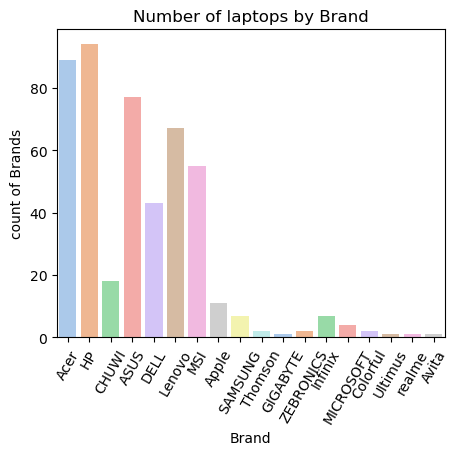

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(5,4))
sns.countplot(data=df,x="Brand",palette="pastel",hue='Brand')
plt.title('Number of laptops by Brand')
plt.ylabel('count of Brands')
plt.xlabel('Brand')
plt.xticks(rotation=60)
plt.show()

**Dominant Brands** : HP, Acer,ASUS and Lenovo have the highest number of laptop listings, indicating they have a significant presence on Flipkart compared to other brands.

- Smaller brands like Avita, Ultimus,Thomson,GIGABYTE,ZEBRONICS and colorful have very few listings, suggesting limited market availability or popularity.



In [146]:
data=df[["Brand"]].value_counts()
data=pd.DataFrame(data)
data

,count
Brand,
HP,94
Acer,89
ASUS,77
Lenovo,67
MSI,55
DELL,43
CHUWI,18
Apple,11
SAMSUNG,7


<Axes: xlabel='rating', ylabel='Density'>

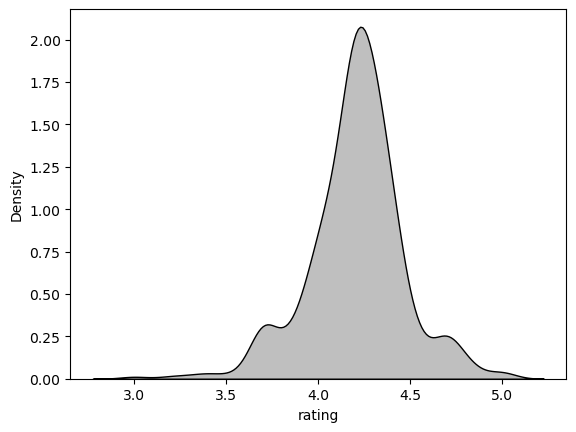

In [148]:
sns.kdeplot(data=df,x="rating",fill=True,color="black")

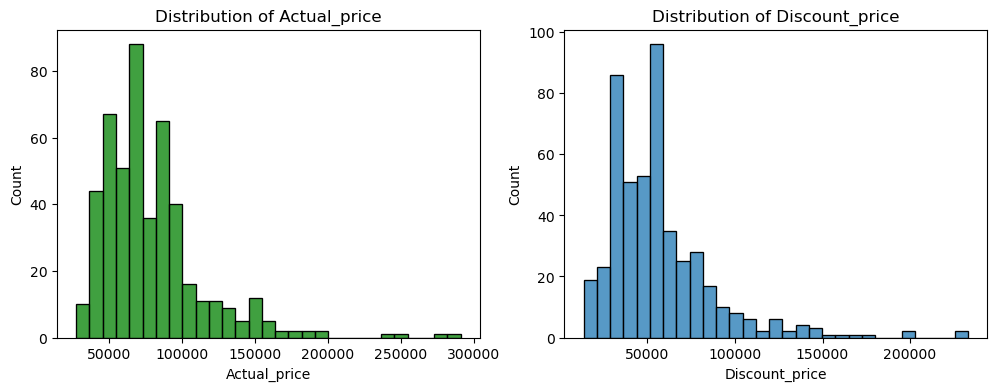

In [150]:
fig, ax= plt.subplots(1, 2, figsize=(12,4))
sns.histplot(data=df,x='Actual_price',ax=ax[0],color="green")
sns.histplot(data=df,x='Discount_price',ax=ax[1])
ax[0].set_title("Distribution of Actual_price")
ax[1].set_title("Distribution of Discount_price")
plt.show()

- The Actual Price distribution is right-skewed, with most laptops priced between ₹40,000 and ₹100,000, and very few beyond ₹150,000.

- The Discount Price distribution shows a leftward shift, with most laptops priced between ₹30,000 and ₹70,000 after discounts.

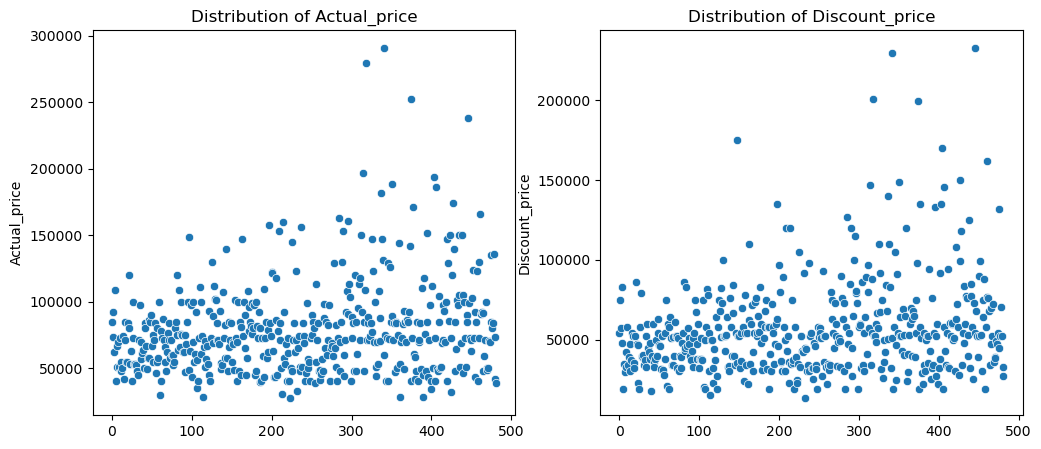

In [152]:
fig, ax= plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df['Actual_price'],ax=ax[0])
sns.scatterplot(data=df['Discount_price'],ax=ax[1])
ax[0].set_title("Distribution of Actual_price")
ax[1].set_title("Distribution of Discount_price")
plt.show()

- Both scatter plots indicate that most laptops cluster within the ₹50,000 to ₹100,000 range for both actual and discount prices, with few premium-priced models above ₹150,000.

- There is a consistent discount trend, as the discount prices remain noticeably lower than actual prices for similar products.

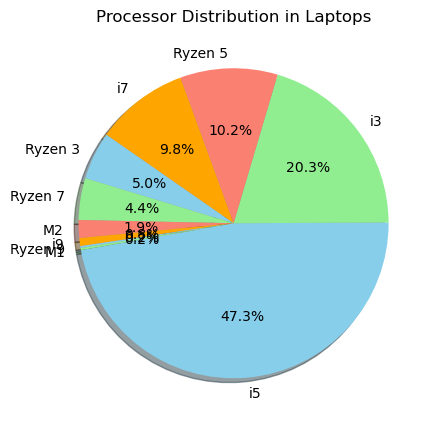

In [155]:
plt.figure(figsize=(5,10))
df['processors'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    shadow=True, 
    colors=['skyblue', 'lightgreen', 'salmon', 'orange'],
    startangle=190
)
plt.title('Processor Distribution in Laptops')
plt.ylabel('')  # Remove the y-axis label
plt.show()

In [157]:
df["processors"].value_counts()

processors
i5         228
i3          98
Ryzen 5     49
i7          47
Ryzen 3     24
Ryzen 7     21
M2           9
i9           4
Ryzen 9      1
M1           1
Name: count, dtype: int64

In [159]:
df['Storage'] = df['Storage'].replace({500: 256, 24: 256})

In [161]:
df['Storage']= df['Storage'].replace({32:512})

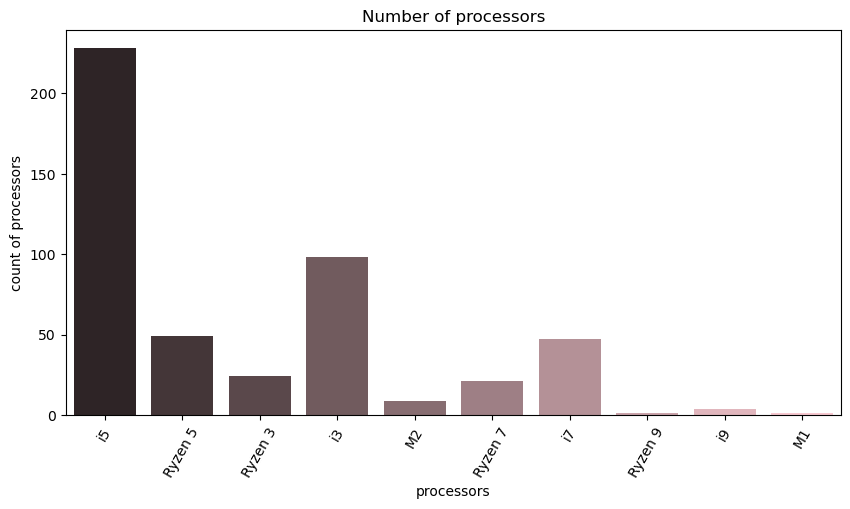

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.countplot(data=df,x="processors",palette='dark:pink',hue='processors')
plt.title('Number of processors')
plt.ylabel('count of processors')
plt.xlabel('processors')
plt.xticks(rotation=60)
plt.show()

- **"i5" processors have the highest demand in the market**

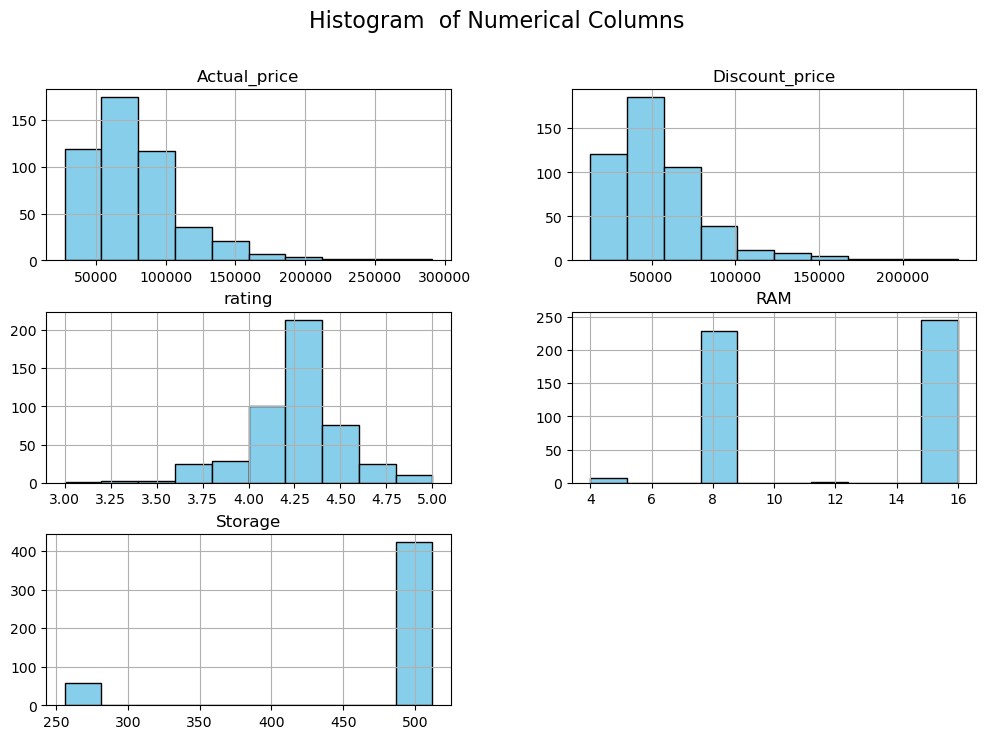

In [166]:
# Numerical columns to visualize
num_cols = ['Actual_price', 'Discount_price', 'rating', 'RAM', 'Storage']

# 1. Plot histograms for each column
df[num_cols].hist(figsize=(12, 8), color='skyblue', edgecolor='black')
plt.suptitle('Histogram  of Numerical Columns', fontsize=16)
plt.show()

# Bivariate Analysis

**Numerical v/s Categorical**

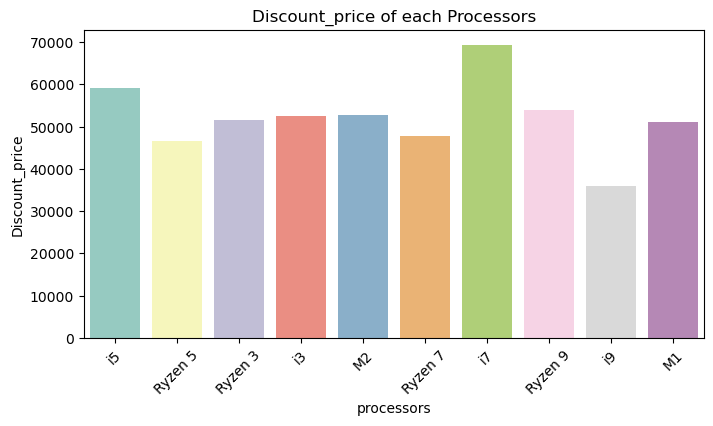

In [169]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='processors', y='Discount_price', hue='processors', palette="Set3",errorbar=None)
plt.title('Discount_price of each Processors')
plt.xticks(rotation=45)
plt.show()

In [171]:
print(df.loc[df["processors"]=="i9","Discount_price"].min())
print(df.loc[df["processors"]=="i9","Discount_price"].max())

18990
71990


In [173]:
df[df["processors"]=="i9"]

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
393,DELL,47869,34250,4.2,8,512,i9,Windows 11
405,CHUWI,72718,18990,4.4,8,256,i9,Windows 11
423,Infinix,149900,71990,4.0,8,256,i9,Windows 11
458,CHUWI,39990,18990,4.4,8,512,i9,Windows 11


### Categorical v/s Categorical

In [178]:
brand_processor_count = df.groupby(['Brand', 'processors']).size().reset_index(name='count')
pd.DataFrame(brand_processor_count)

,Brand,processors,count
0,ASUS,M2,1
1,ASUS,Ryzen 3,4
2,ASUS,Ryzen 5,7
3,ASUS,Ryzen 7,3
4,ASUS,i3,18
...,...,...,...
69,Thomson,i5,2
70,Ultimus,Ryzen 5,1
71,ZEBRONICS,Ryzen 7,1
72,ZEBRONICS,i5,1


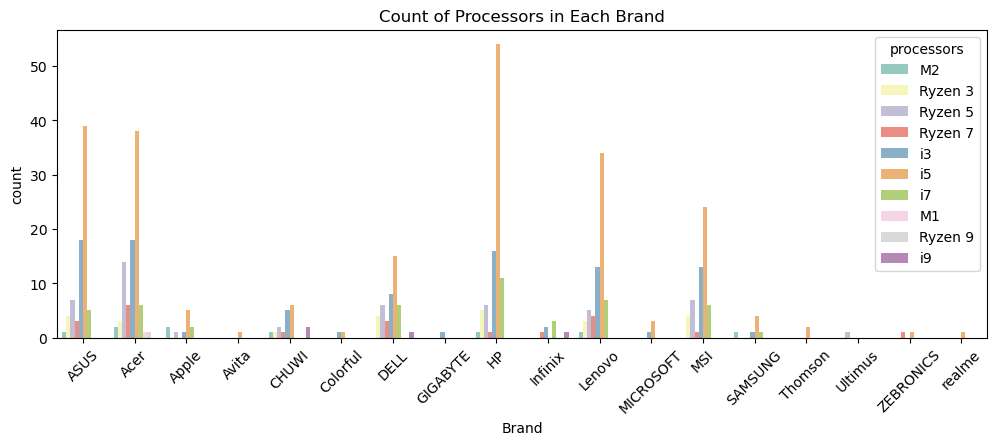

In [180]:
# Plotting
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
sns.barplot(data=brand_processor_count, x='Brand', y='count', hue='processors', palette="Set3")
plt.title('Count of Processors in Each Brand')
plt.xticks(rotation=45)
plt.show()

 * The **i5** processor appears to be the most commonly featured processor across several brands like ASUS, Acer, HP, and others.
 * Processors like **M1, M2**, and **Ryzen 9** have fewer counts, indicating their high-end market positioning.

#  Numerical v/s categorical

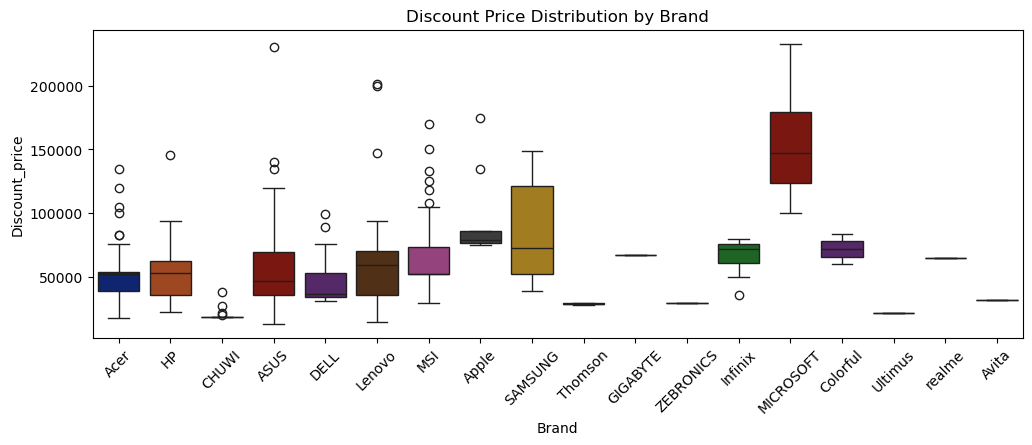

In [182]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
sns.boxplot(data=df, x='Brand', y='Discount_price',palette="dark",hue="Brand",legend=False)
plt.title('Discount Price Distribution by Brand')
plt.xticks(rotation=45)
plt.show()

- Samsung and Apple have the highest price ranges, with Apple showing consistent premium pricing, while Samsung exhibits greater variability.

- Acer, HP, and Dell maintain mid-range pricing with some high-end outliers.

- Budget brands like Thomson, CHUWI, and Colorful have consistently lower prices, targeting cost-conscious buyers.

- Microsoft laptops are priced on the higher side with relatively less price spread, indicating a focus on premium models with consistent pricing.

In [431]:
df

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,Acer,84999,53990,4.3,16,512,i5,Windows 11
1,HP,92110,74990,4.4,16,512,i5,Windows 11
2,HP,73688,56990,4.3,16,512,i5,Windows 11
3,HP,62526,47990,4.2,16,512,i5,Windows 11
4,Acer,108799,82990,4.4,16,512,Ryzen 5,Windows 11
...,...,...,...,...,...,...,...,...
477,Acer,83999,51990,4.3,8,512,i5,Windows 11
478,Lenovo,135690,70290,4.1,16,512,Ryzen 3,Windows 11
479,HP,73400,51990,4.2,16,512,Ryzen 3,Windows 11
480,Acer,41999,32990,4.2,8,512,i5,Windows 11


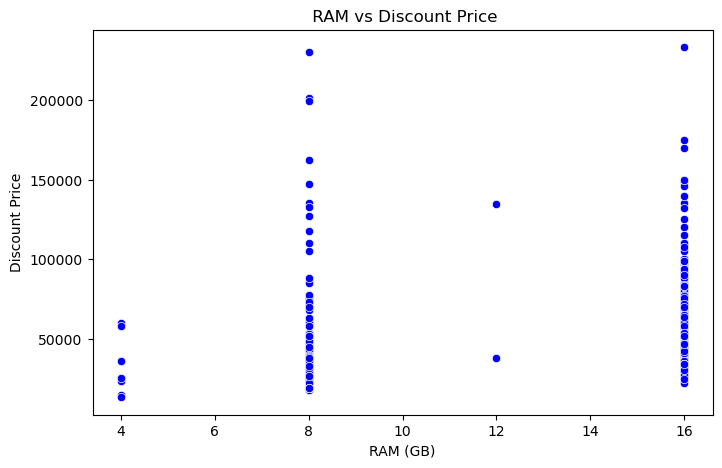

In [184]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['RAM'], y=df['Discount_price'], color='blue')
plt.title(' RAM vs Discount Price')
plt.xlabel('RAM (GB)')
plt.ylabel('Discount Price')
plt.show()

In [186]:
df.loc[df["RAM"]==12,"Discount_price"]

402     37990
403    134900
Name: Discount_price, dtype: int32

# Numerical v/s Numerical

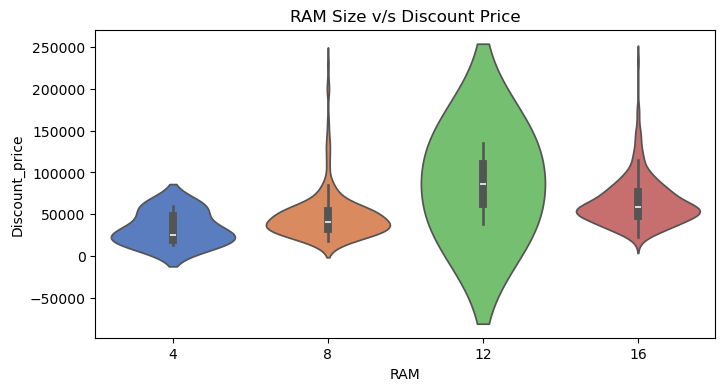

In [188]:
plt.figure(figsize=(8,4))
sns.violinplot(data=df, x='RAM', y='Discount_price', palette='muted',hue="RAM",legend=False)
plt.title('RAM Size v/s Discount Price')
plt.show()

C:\Users\ARSH\AppData\Local\Temp\ipykernel_8240\2724331636.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='RAM', y='Discount_price', data=df, palette='Set2')


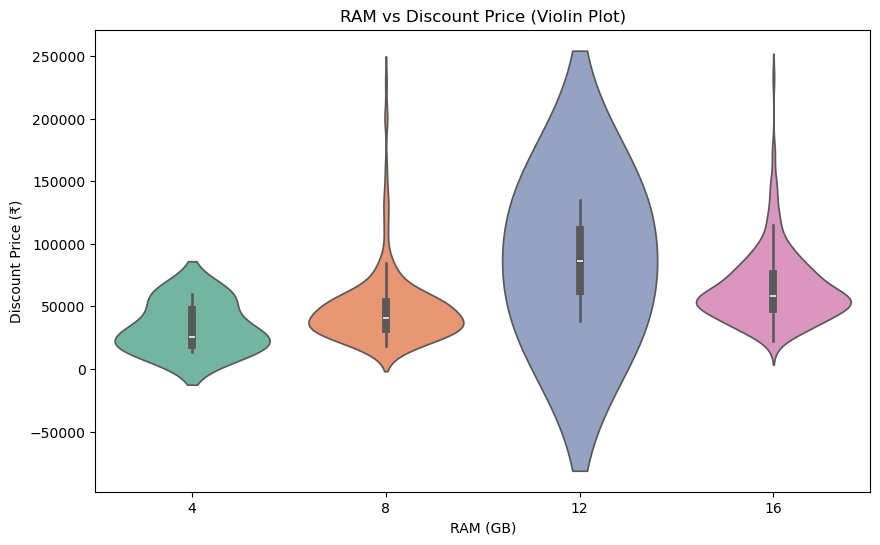

In [437]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.violinplot(x='RAM', y='Discount_price', data=df, palette='Set2')
plt.title('RAM vs Discount Price (Violin Plot)')
plt.xlabel('RAM (GB)')
plt.ylabel('Discount Price (₹)')
plt.show()

In [190]:
df["RAM"].value_counts()

RAM
16    245
8     228
4       7
12      2
Name: count, dtype: int64

In [192]:
print(df.loc[df["RAM"]==4,"Discount_price"].min())
print(df.loc[df["RAM"]==4,"Discount_price"].max())

13490
59990


In [194]:
print(df.loc[df["RAM"]==12,"Discount_price"].min())
print(df.loc[df["RAM"]==12,"Discount_price"].max())

37990
134900


In [196]:
df.loc[df["RAM"]==12]

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
402,CHUWI,49990,37990,4.0,12,512,i3,Windows 11
403,Apple,193990,134900,4.5,12,256,i7,Windows 11


In [198]:
df.loc[(df["Discount_price"]<=ll) | (df["Discount_price"]>=ul),"Discount_price"]

148    174900
163    109990
197    134990
209    119990
214    119990
232     13490
285    126990
290    119990
295    114990
314    146990
318    200990
325    109990
337    139988
338    109990
341    229990
350    148990
359    119990
374    199490
377    134990
395    132990
403    134900
404    169990
407    145990
427    149990
428    117990
438    124990
446    232990
461    161990
475    131990
Name: Discount_price, dtype: int32

- Laptops with 12 GB RAM show the widest price variation, indicating a mix of budget and premium models in this category.

- 4 GB and 8 GB RAM laptops generally cluster within lower discount price ranges, likely catering to budget-conscious buyers.

- 16 GB RAM laptops show a relatively narrow distribution around higher prices, suggesting a more stable pricing pattern for high-performance models.

In [446]:
# in the above plot 

# Catagorical v/s Numerical

C:\Users\ARSH\AppData\Local\Temp\ipykernel_10788\63653224.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='processors', y='rating', data=df, palette='Set2')


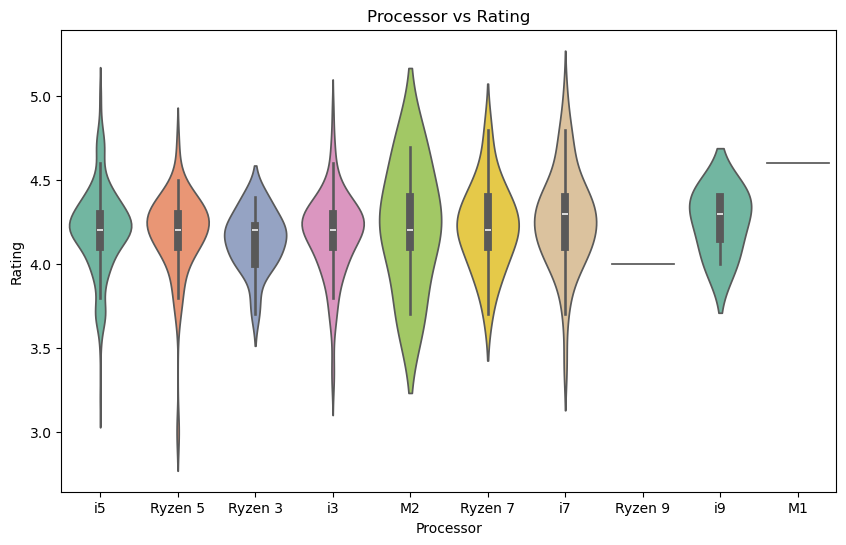

In [200]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='processors', y='rating', data=df, palette='Set2')

# Set plot titles and labels
plt.title('Processor vs Rating')
plt.xlabel('Processor')
plt.ylabel('Rating')
plt.show()

In [202]:
df.loc[df['processors']=="i5","rating"]

0      4.3
1      4.4
2      4.3
3      4.2
6      4.2
      ... 
472    4.4
475    3.8
476    4.3
477    4.3
480    4.2
Name: rating, Length: 228, dtype: float64

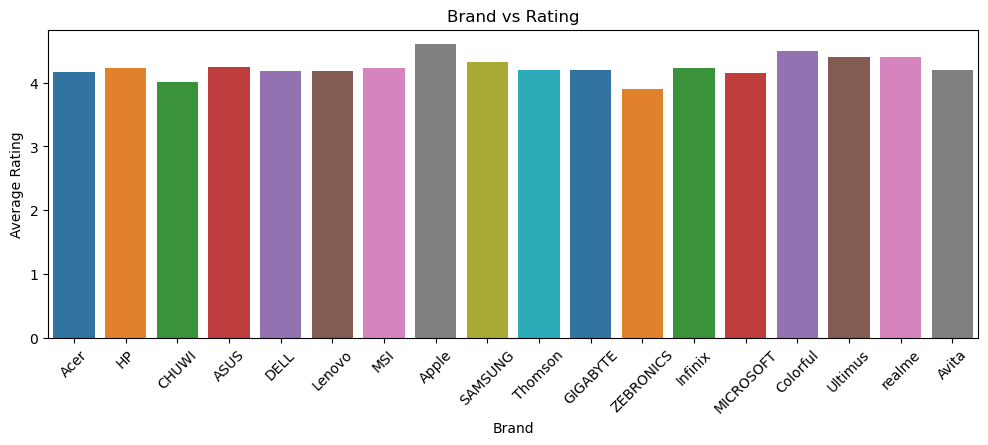

In [204]:
# Bar plot for Brand vs Rating
plt.figure(figsize=(12,4))
sns.barplot(data=df, x='Brand', y='rating', palette='tab10',hue="Brand",errorbar=None)
plt.title('Brand vs Rating')
plt.xlabel('Brand')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

- Most brands have average ratings clustered close to 4, indicating overall high customer satisfaction across the different brands.
    
- Brands such as Acer, HP, and Dell show a rating similar to more premium brands like Apple and Microsoft, suggesting competitive performance even among budget-friendly options.

In [206]:
df

,Brand,Actual_price,Discount_price,rating,RAM,Storage,processors,windows
0,Acer,84999,53990,4.3,16,512,i5,Windows 11
1,HP,92110,74990,4.4,16,512,i5,Windows 11
2,HP,73688,56990,4.3,16,512,i5,Windows 11
3,HP,62526,47990,4.2,16,512,i5,Windows 11
4,Acer,108799,82990,4.4,16,512,Ryzen 5,Windows 11
...,...,...,...,...,...,...,...,...
477,Acer,83999,51990,4.3,8,512,i5,Windows 11
478,Lenovo,135690,70290,4.1,16,512,Ryzen 3,Windows 11
479,HP,73400,51990,4.2,16,512,Ryzen 3,Windows 11
480,Acer,41999,32990,4.2,8,512,i5,Windows 11


# Multivariate Analysis

In [209]:
c=df.groupby(by=["Brand","processors","RAM","windows"])[["Actual_price","Discount_price"]].agg(["min","max","mean","median"])
c

Actual_price                        \
                                             min     max          mean   
Brand     processors RAM windows                                         
ASUS      M2         8   Windows 11        39990   39990  39990.000000   
          Ryzen 3    4   Windows 11        32990   32990  32990.000000   
                     8   Windows 11        50990  170990  94656.666667   
          Ryzen 5    8   Windows 11        49990   74990  64490.000000   
                     16  Windows 11        70990  122990  91323.333333   
...                                          ...     ...           ...   
Thomson   i5         16  Windows 11        59990   59990  59990.000000   
Ultimus   Ryzen 5    8   Windows 11        40990   40990  40990.000000   
ZEBRONICS Ryzen 7    8   Windows 11        60999   60999  60999.000000   
          i5         8   Windows 11        60999   60999  60999.000000   
realme    i5         16  Windows 11        74999   74999  74999.000000   

                                             Discount_price                    \
                                      median            min     max      mean   
Brand     processors RAM windows                                                
ASUS      M2         8   Windows 11  39990.0          23990   23990  23990.00   
          Ryzen 3    4   Windows 11  32990.0          13490   13490  13490.00   
                     8   Windows 11  61990.0          36990  134990  70650.00   
          Ryzen 5    8   Windows 11  66490.0          35700   42990  39703.25   
                     16  Windows 11  79990.0          40980   91990  62320.00   
...                                      ...            ...     ...       ...   
Thomson   i5         16  Windows 11  59990.0          29990   29990  29990.00   
Ultimus   Ryzen 5    8   Windows 11  40990.0          21990   21990  21990.00   
ZEBRONICS Ryzen 7    8   Windows 11  60999.0          29990   29990  29990.00   
          i5         8   Windows 11  60999.0          29990   29990  29990.00   
realme    i5         16  Windows 11  74999.0          64999   64999  64999.00   

                                              
                                      median  
Brand     processors RAM windows              
ASUS      M2         8   Windows 11  23990.0  
          Ryzen 3    4   Windows 11  13490.0  
                     8   Windows 11  39970.0  
          Ryzen 5    8   Windows 11  40061.5  
                     16  Windows 11  53990.0  
...                                      ...  
Thomson   i5         16  Windows 11  29990.0  
Ultimus   Ryzen 5    8   Windows 11  21990.0  
ZEBRONICS Ryzen 7    8   Windows 11  29990.0  
          i5         8   Windows 11  29990.0  
realme    i5         16  Windows 11  64999.0  

[118 rows x 8 columns]

In [225]:
c=df.groupby(by=["Brand","processors","RAM","windows","Storage"])[["Actual_price","Discount_price"]].agg(["min","max","mean","median"])
c

Actual_price          \
                                                     min     max   
Brand     processors RAM windows    Storage                        
ASUS      M2         8   Windows 11 256            39990   39990   
          Ryzen 3    4   Windows 11 512            32990   32990   
                     8   Windows 11 512            50990  170990   
          Ryzen 5    8   Windows 11 512            49990   74990   
                     16  Windows 11 256            70990   70990   
...                                                  ...     ...   
Thomson   i5         16  Windows 11 512            59990   59990   
Ultimus   Ryzen 5    8   Windows 11 512            40990   40990   
ZEBRONICS Ryzen 7    8   Windows 11 512            60999   60999   
          i5         8   Windows 11 512            60999   60999   
realme    i5         16  Windows 11 512            74999   74999   

                                                                    \
                                                     mean   median   
Brand     processors RAM windows    Storage                          
ASUS      M2         8   Windows 11 256      39990.000000  39990.0   
          Ryzen 3    4   Windows 11 512      32990.000000  32990.0   
                     8   Windows 11 512      94656.666667  61990.0   
          Ryzen 5    8   Windows 11 512      64490.000000  66490.0   
                     16  Windows 11 256      70990.000000  70990.0   
...                                                   ...      ...   
Thomson   i5         16  Windows 11 512      59990.000000  59990.0   
Ultimus   Ryzen 5    8   Windows 11 512      40990.000000  40990.0   
ZEBRONICS Ryzen 7    8   Windows 11 512      60999.000000  60999.0   
          i5         8   Windows 11 512      60999.000000  60999.0   
realme    i5         16  Windows 11 512      74999.000000  74999.0   

                                            Discount_price                    \
                                                       min     max      mean   
Brand     processors RAM windows    Storage                                    
ASUS      M2         8   Windows 11 256              23990   23990  23990.00   
          Ryzen 3    4   Windows 11 512              13490   13490  13490.00   
                     8   Windows 11 512              36990  134990  70650.00   
          Ryzen 5    8   Windows 11 512              35700   42990  39703.25   
                     16  Windows 11 256              40980   40980  40980.00   
...                                                    ...     ...       ...   
Thomson   i5         16  Windows 11 512              29990   29990  29990.00   
Ultimus   Ryzen 5    8   Windows 11 512              21990   21990  21990.00   
ZEBRONICS Ryzen 7    8   Windows 11 512              29990   29990  29990.00   
          i5         8   Windows 11 512              29990   29990  29990.00   
realme    i5         16  Windows 11 512              64999   64999  64999.00   

                                                      
                                              median  
Brand     processors RAM windows    Storage           
ASUS      M2         8   Windows 11 256      23990.0  
          Ryzen 3    4   Windows 11 512      13490.0  
                     8   Windows 11 512      39970.0  
          Ryzen 5    8   Windows 11 512      40061.5  
                     16  Windows 11 256      40980.0  
...                                              ...  
Thomson   i5         16  Windows 11 512      29990.0  
Ultimus   Ryzen 5    8   Windows 11 512      21990.0  
ZEBRONICS Ryzen 7    8   Windows 11 512      29990.0  
          i5         8   Windows 11 512      29990.0  
realme    i5         16  Windows 11 512      64999.0  

[149 rows x 8 columns]

<Figure size 500x200 with 0 Axes>

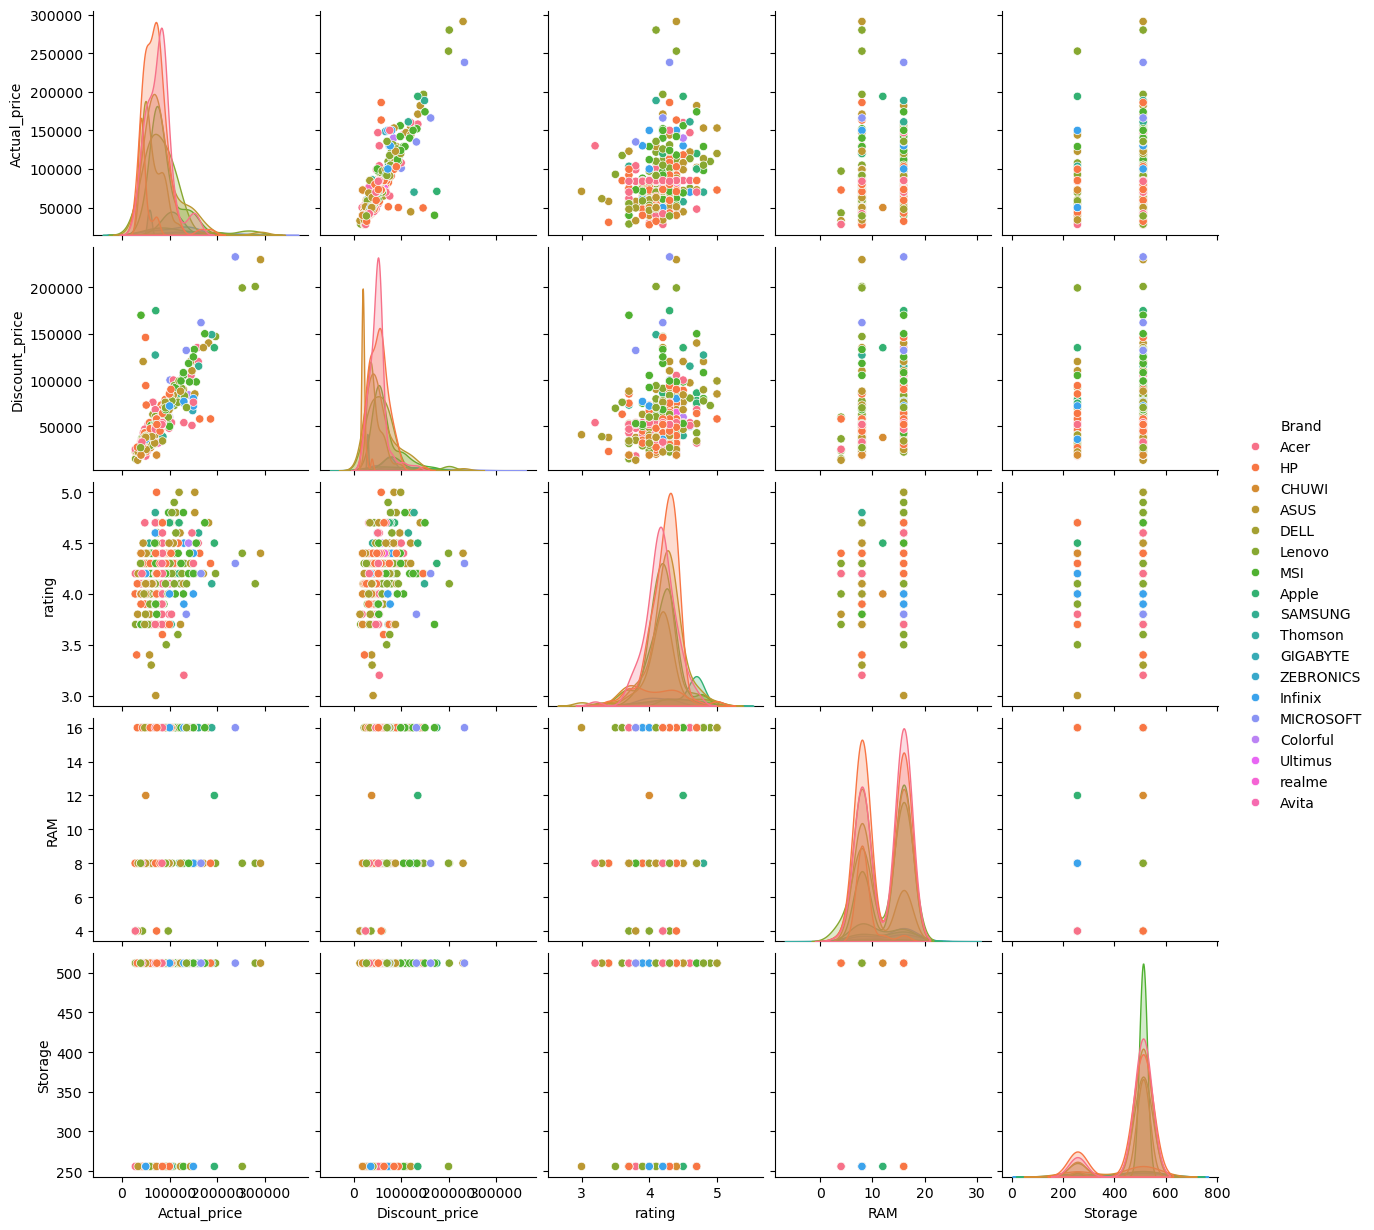

In [211]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,2))
sns.pairplot(df,hue='Brand')
plt.show()

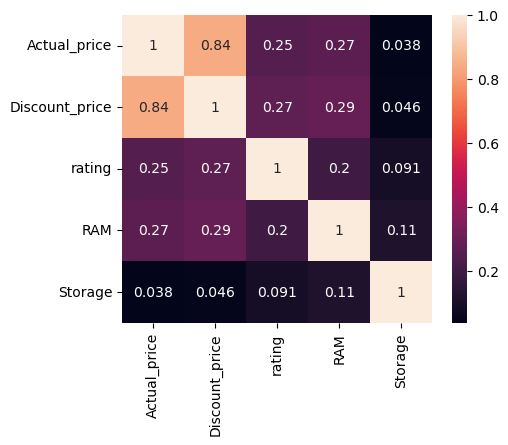

In [215]:
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [227]:
c1 = c.reset_index()

### PROJECT on pricing Analysis of Laptops**
   
**By Niharika,Kavya,Arshiya** 